# `LinearScheduler`

This notebook provides an empirical demonstration of the expected behavior of a `LinearScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is linear scheduling across depth. A `LinearScheduler` changes its value at a constant rate as depth increases, while respecting the configured lower and upper bounds.

## Conceptual Overview

A `LinearScheduler` defines a linear relationship between depth and scheduled value. For a slope $m$ and intercept $b$, the unconstrained value at depth $d$ is

$$
S(d)=md+b.
$$

The slope determines the rate at which the scheduled value changes with depth, and the intercept shifts the resulting relationship vertically. The configured minimum and maximum values bound the schedule within the permitted range.

### Scope of the demonstration

The experiment evaluates a `LinearScheduler` over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.schedulers import LinearScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`SLOPE = 0.1` determines the rate at which the scheduled value increases with depth.

`INTERCEPT = 0` leaves the linear relationship vertically unshifted.

`MIN_VALUE = 0` and `MAX_VALUE = 1000` define the lower and upper bounds of the schedule.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
SLOPE = 0.1
INTERCEPT = 0
MIN_VALUE = 0
MAX_VALUE = 1000

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `LinearScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: LinearScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (LinearScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Linear Scheduler "
        f"(slope={SLOPE}, intercept={INTERCEPT}, "
        f"min_value={MIN_VALUE}, max_value={MAX_VALUE})"
    )
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows the scheduled value increasing linearly from `0` at depth `0` to `1000` at depth `10000`. Equal increases in depth produce equal increases in value throughout the displayed range.

The straight-line trajectory confirms that the scheduler applies the configured slope consistently while remaining within its configured bounds.

In [4]:
# initialize a LinearScheduler
scheduler = LinearScheduler(
    slope=SLOPE,
    intercept=INTERCEPT,
    min_value=MIN_VALUE,
    max_value=MAX_VALUE,
)

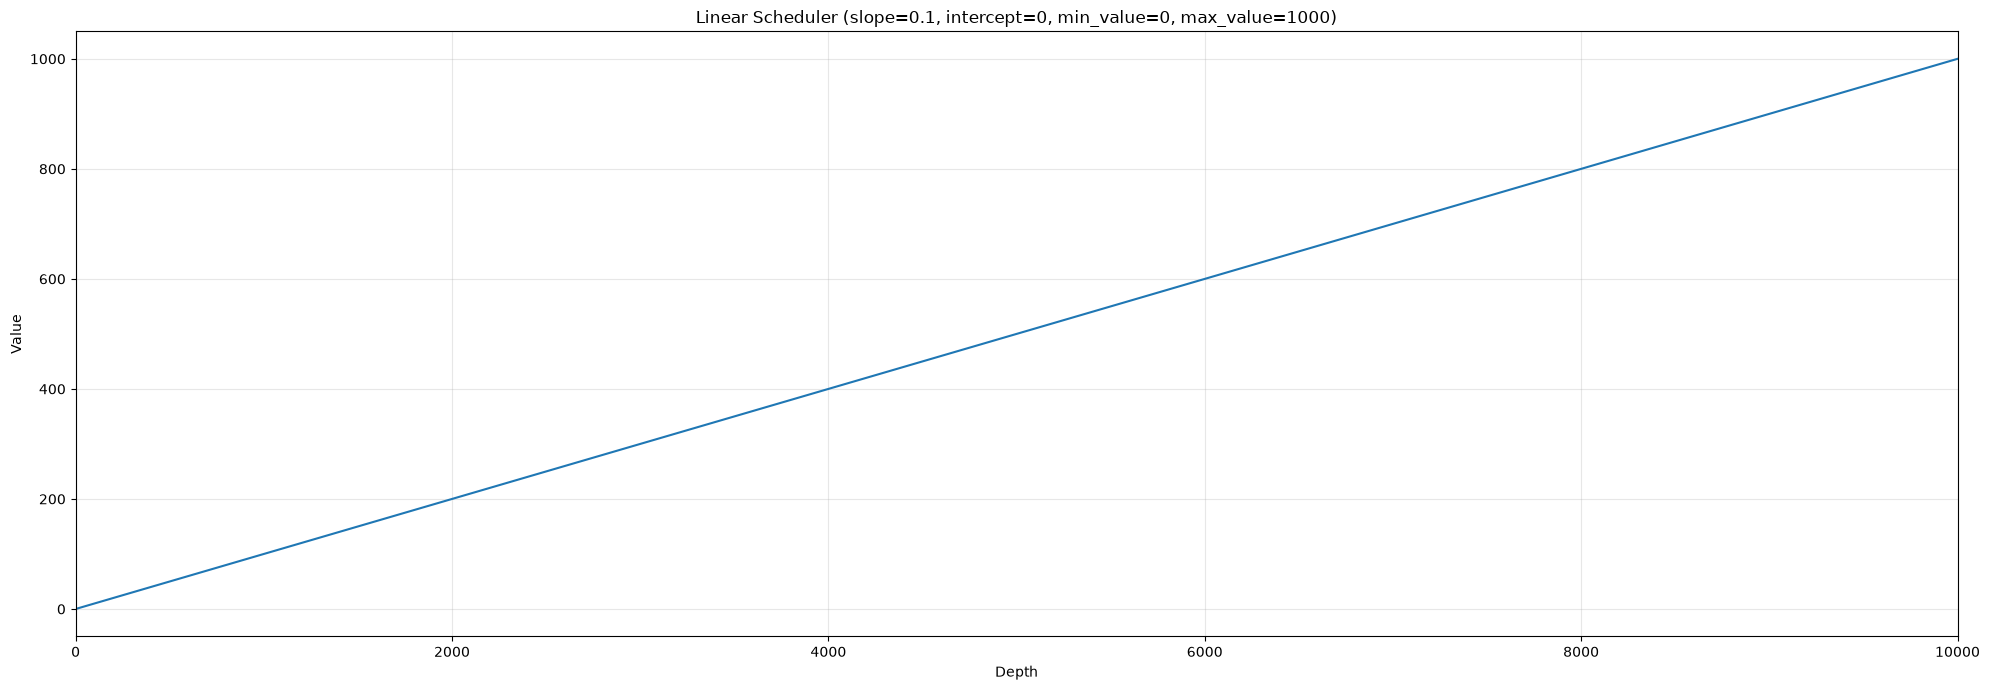

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how a `LinearScheduler` maps depth to a value that changes at a constant rate. The configured slope determines that rate of change, while the minimum and maximum values constrain the resulting schedule.

Examined in isolation, the module exhibits its intended behavior: it implements a bounded linear scheduling strategy in which the scheduled value varies linearly with depth.